In [3]:
import sys
import os

from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'hERG_mlp.csv')
df_existing = pd.read_csv(csv_filename)


In [4]:
df_existing = df_existing.sort_values(by="mcc", ascending=False)

In [5]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
735,736,0.432115,0.773270,0.727099,133.261373,0.894616,187,0.006551,0.049417,558,512,AdamW,0.00010,"[4096, 1024, 256, 64, 8]"
912,913,0.431943,0.771284,0.726460,129.902783,0.313820,77,0.000031,0.000002,1911,64,AdamW,0.00010,[200]
879,880,0.430777,0.773904,0.726779,56.623326,0.642643,20,0.000063,0.000281,1354,64,AdamW,0.00010,"[1000, 50]"
969,970,0.428984,0.769519,0.724864,33.982390,0.102211,55,0.002442,0.000034,1963,128,AdamW,0.00010,[200]
864,865,0.428984,0.769519,0.724864,116.365534,0.522548,130,0.000256,0.100000,1749,128,AdamW,0.00010,[200]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,684,-0.041517,0.513522,0.477498,46.051559,0.214260,115,0.000910,0.039069,1250,1024,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
850,851,-0.041517,0.513522,0.477498,21.653428,0.687862,11,0.000031,0.000001,245,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
557,558,-0.065613,0.444229,0.451325,31.355584,0.868965,26,0.003728,0.012068,1756,256,RMSprop,0.00001,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
278,279,-0.068673,0.691224,0.545164,72.282222,0.546922,197,0.000047,0.000003,1214,1024,RMSprop,1.00000,[200]


In [6]:
display(df_existing.iloc[0])

run_id                                   736
mcc                                 0.432115
f1                                   0.77327
acc                                 0.727099
duration_seconds                  133.261373
dropout_frac                        0.894616
patience                                 187
tol                                 0.006551
weight_decay                        0.049417
n_epochs                                 558
batch_size                               512
optimizer                              AdamW
lr                                    0.0001
neuron_layers       [4096, 1024, 256, 64, 8]
Name: 735, dtype: object

In [7]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

In [8]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
735,736,0.432115,0.773270,0.727099,133.261373,0.894616,187,0.006551,0.049417,558,512,AdamW,0.00010,"[4096, 1024, 256, 64, 8]"
912,913,0.431943,0.771284,0.726460,129.902783,0.313820,77,0.000031,0.000002,1911,64,AdamW,0.00010,[200]
879,880,0.430777,0.773904,0.726779,56.623326,0.642643,20,0.000063,0.000281,1354,64,AdamW,0.00010,"[1000, 50]"
969,970,0.428984,0.769519,0.724864,33.982390,0.102211,55,0.002442,0.000034,1963,128,AdamW,0.00010,[200]
864,865,0.428984,0.769519,0.724864,116.365534,0.522548,130,0.000256,0.100000,1749,128,AdamW,0.00010,[200]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,684,-0.041517,0.513522,0.477498,46.051559,0.214260,115,0.000910,0.039069,1250,1024,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
850,851,-0.041517,0.513522,0.477498,21.653428,0.687862,11,0.000031,0.000001,245,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
557,558,-0.065613,0.444229,0.451325,31.355584,0.868965,26,0.003728,0.012068,1756,256,RMSprop,0.00001,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
278,279,-0.068673,0.691224,0.545164,72.282222,0.546922,197,0.000047,0.000003,1214,1024,RMSprop,1.00000,[200]


In [9]:
best_results = df_existing.iloc[:3]

In [10]:
best_results

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
735,736,0.432115,0.773270,0.727099,133.261373,0.894616,187,0.006551,0.049417,558,512,AdamW,0.0001,"[4096, 1024, 256, 64, 8]"
912,913,0.431943,0.771284,0.726460,129.902783,0.313820,77,0.000031,0.000002,1911,64,AdamW,0.0001,[200]
879,880,0.430777,0.773904,0.726779,56.623326,0.642643,20,0.000063,0.000281,1354,64,AdamW,0.0001,"[1000, 50]"


In [11]:
best_results = best_results.iloc[:, 5:]

In [12]:
best_results_mlp_dicts = []
for i,j in best_results.iterrows():
    best_results_mlp_dicts.append(dict(j))

In [13]:
best_results_mlp_dicts

[{'dropout_frac': 0.8946158157218873,
  'patience': 187,
  'tol': 0.0065512855685955,
  'weight_decay': 0.0494171336132383,
  'n_epochs': 558,
  'batch_size': 512,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[4096, 1024, 256, 64, 8]'},
 {'dropout_frac': 0.3138196502794462,
  'patience': 77,
  'tol': 3.0888435964774785e-05,
  'weight_decay': 2.023589647725156e-06,
  'n_epochs': 1911,
  'batch_size': 64,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[200]'},
 {'dropout_frac': 0.6426426318065188,
  'patience': 20,
  'tol': 6.250551925273976e-05,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 1354,
  'batch_size': 64,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[1000, 50]'}]

In [14]:

df_existing_svc = pd.read_csv("res/svc_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:2].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :3]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,gamma,kernel,mcc,f1,acc
0,0,0.001,0.01,linear,0.381949,0.753577,0.703160
1,2,0.001,0.01,poly,0.366902,0.678061,0.669327
2,12,0.010,0.01,linear,0.348130,0.740878,0.687201
3,14,0.010,0.01,poly,0.336925,0.654878,0.651133
4,26,0.100,0.01,poly,0.327989,0.660043,0.650495
...,...,...,...,...,...,...,...
67,54,10.000,1.00,linear,-2.000000,-1.000000,-1.000000
68,57,10.000,10.00,linear,-2.000000,-1.000000,-1.000000
69,63,100.000,0.10,linear,-2.000000,-1.000000,-1.000000
70,66,100.000,1.00,linear,-2.000000,-1.000000,-1.000000


In [15]:
best_results_svc_dicts

[{'C': 0.001, 'gamma': 0.01, 'kernel': 'linear'},
 {'C': 0.001, 'gamma': 0.01, 'kernel': 'poly'}]

In [17]:
df_existing_knn = pd.read_csv("res/knn_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:5].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

,0,1,2,3,4,5,6,7,8,9,...,4668,4669,4670,4671,4672,4673,4674,4675,4676,4677
0,-0.368807,0.449969,-2.179742,0.533317,-0.305330,0.565028,1.694528,0.698365,-0.127115,0.181530,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
1,-0.833699,0.984010,-2.094093,1.115777,-0.308247,1.050824,1.285909,0.619204,0.147659,0.597666,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.558479
2,0.718652,-1.241727,-1.294048,0.844113,-1.534152,0.413797,1.438163,-0.134257,0.650031,0.318751,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-1.138625
3,0.457665,-0.959587,-0.958390,0.952259,-1.395083,0.751934,1.598343,-0.201440,0.867544,1.090554,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.931042
4,-0.533496,0.466023,-1.137150,0.533591,-1.182542,0.407465,0.484916,0.602196,0.361761,0.971192,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.946793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9159,-1.372795,-0.408414,-0.269412,-0.296725,0.278256,-0.185780,-0.313672,-0.001844,0.525074,-0.587704,...,-0.223891,1.061998,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.403723
9160,-0.358796,-1.813513,-0.777799,-0.521747,0.828404,-0.579002,0.031730,1.028444,1.603450,-0.841053,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,-0.608933
9161,-0.535688,1.280876,-0.035218,-0.665111,-1.151365,0.063225,-0.018170,-0.169370,0.120780,-0.797153,...,-0.223891,-0.279947,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,-0.270075,0.137063
9162,0.350739,0.666471,2.062234,-0.074140,1.242787,1.830375,-0.051098,-0.894747,-0.933312,-0.810303,...,-0.223891,3.422514,-0.19119,-0.030167,-0.112972,-0.21324,-0.213726,-0.143919,3.659017,1.138819


'SVC'

0.3884107964144226

0.3622419017399172

'KNN'

...

0.3564143643630913

0.3564143643630913

0.3564143643630913

0.3564143643630913

RESULTS FOR CYCLE KNN#1
Accuracy: 0.6658
F1-Score: 0.7316
MCC: 0.2888
RESULTS FOR CYCLE SVC#1
Accuracy: 0.7009
F1-Score: 0.7617
MCC: 0.3604


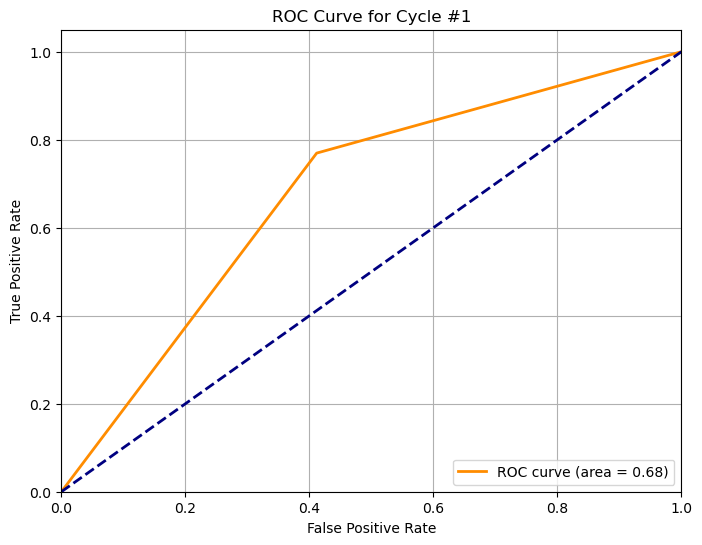

0.44297241553331373

0.4064819130285313

0.43838664025754326

[[0.25523037]
 [0.27903196]
 [0.3320737 ]
 ...
 [0.5843957 ]
 [0.6996026 ]
 [0.7834033 ]]
RESULTS FOR CYCLE MLP#1
Accuracy: 0.7027
F1-Score: 0.7600
MCC: 0.3694


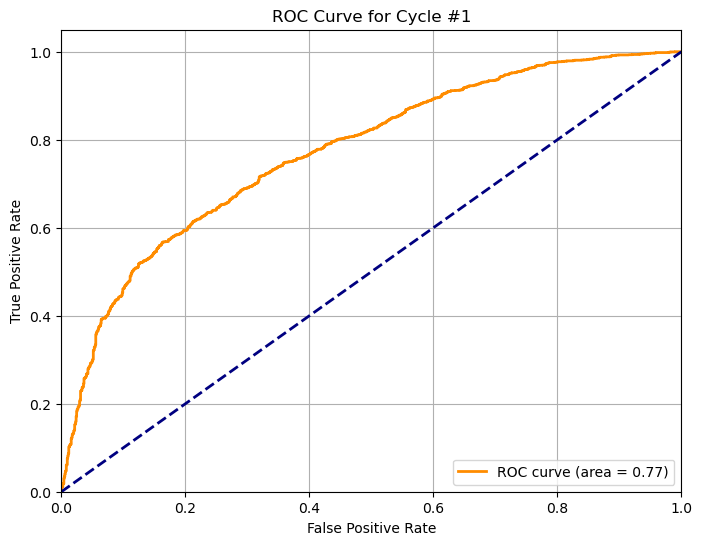

,0,1,2,3,4,5,6,7,8,9,...,4666,4667,4668,4669,4670,4671,4672,4673,4674,4675
0,-0.362184,0.448008,-2.143418,0.530138,-0.257277,0.572114,1.698922,0.634198,-0.142237,0.174387,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-0.571529
1,-0.836567,0.976398,-2.058665,1.097886,-0.260218,1.054428,1.285253,0.556029,0.131488,0.605601,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-0.571529
2,0.747474,-1.225788,-1.266984,0.833084,-1.495864,0.421966,1.439388,-0.187988,0.631942,0.316580,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-1.134060
3,0.481160,-0.946633,-0.934834,0.938499,-1.355690,0.757681,1.601547,-0.254329,0.848624,1.116346,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-0.932779
4,-0.530235,0.463892,-1.111725,0.530405,-1.141460,0.415680,0.474360,0.539234,0.344772,0.992660,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-0.948052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9093,0.120324,0.785933,-0.216017,-0.286127,0.430993,-0.311084,-0.248511,-0.237978,-0.555913,-0.427380,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,0.424181
9094,0.293206,-0.845688,0.481239,-0.299977,0.730745,0.705041,1.100336,0.109833,-0.609579,0.087461,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,2.514562,1.475662
9095,0.221895,-0.310730,-0.141808,0.650257,-1.407081,-0.493038,1.134436,1.209638,-0.119294,0.403514,...,-0.215611,3.750437,-0.185732,-0.02532,-0.080301,-0.135273,-0.185732,-0.128648,-0.285210,0.580396
9096,-0.619225,-0.905723,-1.192894,0.500945,0.077592,1.207692,1.286035,1.263293,0.850846,0.308666,...,-0.215611,-0.263333,-0.185732,-0.02532,-0.080301,-0.217930,-0.185732,-0.128648,-0.285210,-1.042586


'SVC'

0.36879136270496343

0.3949936229554125

'KNN'

...

0.3274719878583179

0.3274719878583179

0.3274719878583179

0.3274719878583179

RESULTS FOR CYCLE KNN#2
Accuracy: 0.6464
F1-Score: 0.7153
MCC: 0.2498
RESULTS FOR CYCLE SVC#2
Accuracy: 0.6082
F1-Score: 0.6086
MCC: 0.2758


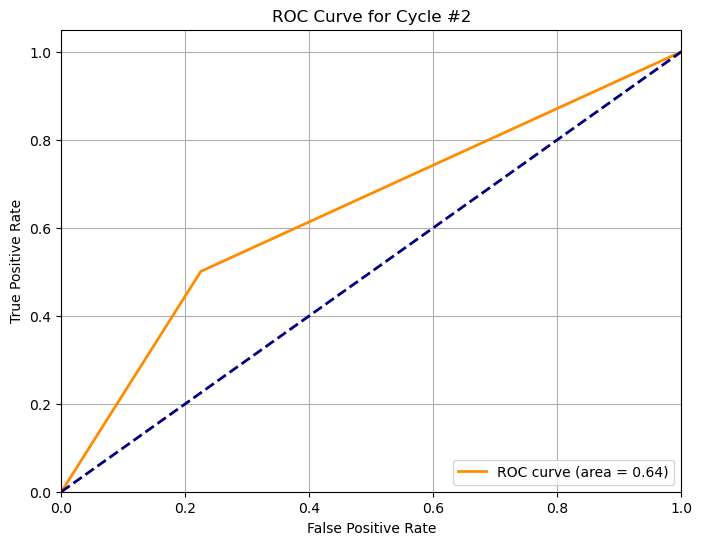

0.3975590048730222

0.39005005907319523

0.38808090975789716

[[0.13530098]
 [0.19868325]
 [0.19506246]
 ...
 [0.77185357]
 [0.7715339 ]
 [0.7565848 ]]
RESULTS FOR CYCLE MLP#2
Accuracy: 0.6894
F1-Score: 0.7367
MCC: 0.3601


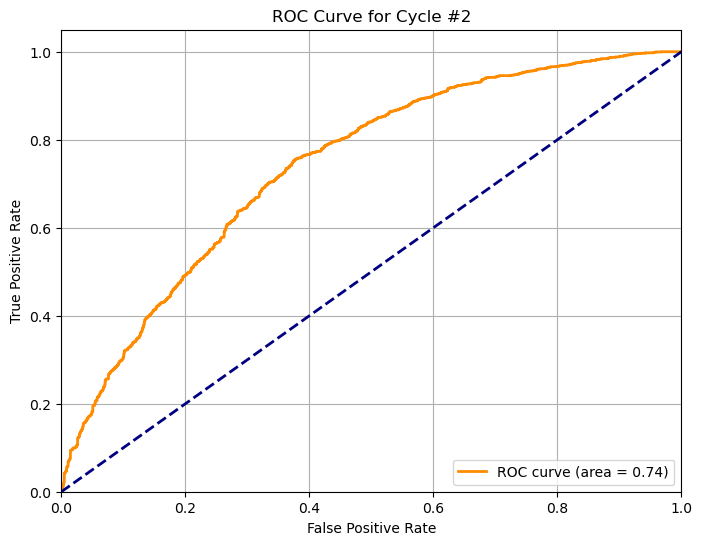

,0,1,2,3,4,5,6,7,8,9,...,4680,4681,4682,4683,4684,4685,4686,4687,4688,4689
0,-0.398179,0.431512,-2.203486,0.499828,-0.323603,0.568428,1.589598,0.664332,-0.161333,0.211176,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-0.503399
1,-0.878038,0.964984,-2.118385,1.073640,-0.326528,1.060180,1.192194,0.584612,0.117462,0.631349,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-0.503399
2,0.724289,-1.258383,-1.323454,0.806009,-1.555767,0.415343,1.340269,-0.174168,0.627185,0.349728,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-1.070193
3,0.454901,-0.976543,-0.989942,0.912550,-1.416320,0.757626,1.496052,-0.241825,0.847881,1.129017,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-0.867387
4,-0.568170,0.447549,-1.167558,0.500098,-1.203201,0.408934,0.413185,0.567484,0.334697,1.008499,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-0.882775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9087,0.065998,-0.140296,0.158861,0.347519,-1.485708,-0.062377,0.941506,1.076934,-0.640654,0.422632,...,-0.298662,3.715406,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,0.935855
9088,-0.518520,-1.028287,-0.075358,0.673880,-0.077676,0.471374,-0.246477,0.078206,0.886339,-0.203543,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,0.033046
9089,1.882504,-0.004193,-1.152108,-0.704159,-0.417925,0.570853,1.240907,1.112134,-0.893980,0.759024,...,-0.298662,-0.266957,0.616495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,0.250068
9090,-0.615102,-0.366688,-0.832443,1.023785,-1.151370,0.730578,1.769984,0.904352,1.102767,1.728658,...,-0.298662,-0.266957,-0.193495,-0.028298,-0.094552,-0.196958,-0.208458,-0.113406,-0.274057,-0.361707


'SVC'

0.34745392357082855

0.33239088864001715

'KNN'

...

0.30927483007380974

0.30927483007380974

0.30927483007380974

0.30927483007380974

RESULTS FOR CYCLE KNN#3
Accuracy: 0.6432
F1-Score: 0.7074
MCC: 0.2507
RESULTS FOR CYCLE SVC#3
Accuracy: 0.6760
F1-Score: 0.7285
MCC: 0.3288


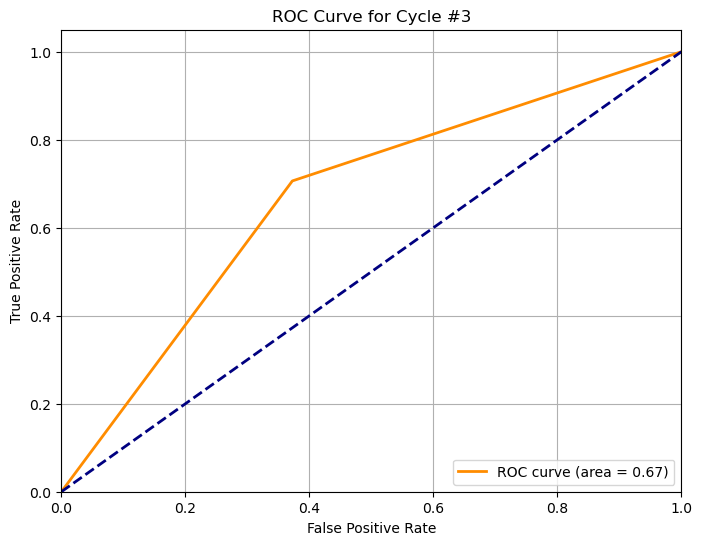

0.38984362093706715

0.4026104132885295

0.40976138840681586

[[0.00687829]
 [0.13760743]
 [0.08711448]
 ...
 [0.9525551 ]
 [0.79059964]
 [0.8232216 ]]
RESULTS FOR CYCLE MLP#3
Accuracy: 0.6994
F1-Score: 0.7461
MCC: 0.3807


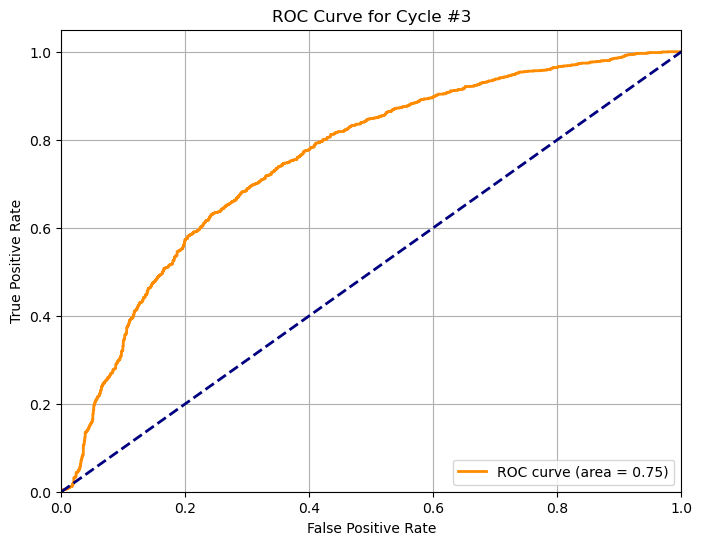

,0,1,2,3,4,5,6,7,8,9,...,4676,4677,4678,4679,4680,4681,4682,4683,4684,4685
0,0.892292,0.428108,0.068017,1.651243,-1.778007,0.059858,-0.943074,-0.485210,-2.144076,0.835728,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,1.044227
1,-0.054598,-1.005188,1.985870,-0.883710,0.023172,0.784987,-2.897275,-2.261713,-2.909205,1.883331,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,0.875599
2,1.111763,-1.062140,1.711932,-0.357771,0.043648,0.084593,-0.490731,-1.578724,-1.482217,0.047688,...,-0.276299,3.536485,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,-0.483177
3,-0.251998,-1.025494,0.570602,-0.706254,0.150545,-0.546945,-1.443216,1.156059,0.899200,-0.026076,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,13.265942,-0.245664,-0.376075
4,-0.432946,-0.850018,1.239028,-0.614498,0.722501,-1.045192,-0.948921,1.765550,1.073140,-0.788237,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,13.265942,-0.245664,-0.376075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9031,-1.715780,-0.597298,1.919236,0.266660,-0.527932,1.092129,0.119027,-0.869842,-0.919969,0.574688,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,0.434669
9032,0.141781,-1.523900,-0.896431,-0.976621,0.512080,-0.581684,-0.578424,1.307326,1.369839,-1.084388,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,-0.479403
9033,-0.354328,0.706565,-0.402620,-0.943145,0.048270,-0.917685,0.641053,1.226591,0.625060,-0.086014,...,-0.276299,-0.275360,4.896183,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,-0.912982
9034,0.277046,0.098624,0.018751,0.320712,1.352001,0.950994,0.111590,-0.491318,-0.311038,0.058408,...,-0.276299,-0.275360,-0.196057,-0.030036,-0.114213,-0.216764,-0.223085,-0.128320,-0.245664,-0.211732


'SVC'

0.40742738485737917

0.4006929916909847

'KNN'

...

0.32105978242744043

0.32105978242744043

0.32105978242744043

0.32105978242744043

RESULTS FOR CYCLE KNN#4
Accuracy: 0.6262
F1-Score: 0.6982
MCC: 0.2072
RESULTS FOR CYCLE SVC#4
Accuracy: 0.6550
F1-Score: 0.7124
MCC: 0.2849


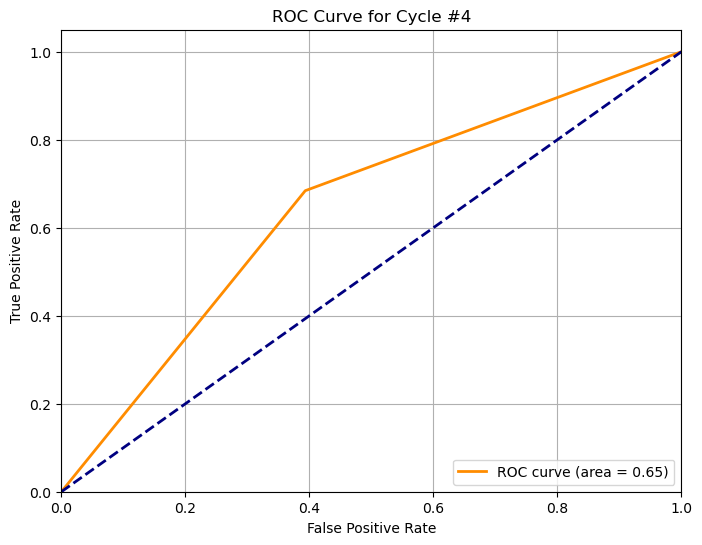

0.41898709482089136

0.41895021423942574

0.4029212180236738

[[0.25419444]
 [0.25261518]
 [0.17043981]
 ...
 [0.6578915 ]
 [0.6427829 ]
 [0.66228765]]
RESULTS FOR CYCLE MLP#4
Accuracy: 0.6637
F1-Score: 0.7275
MCC: 0.2887


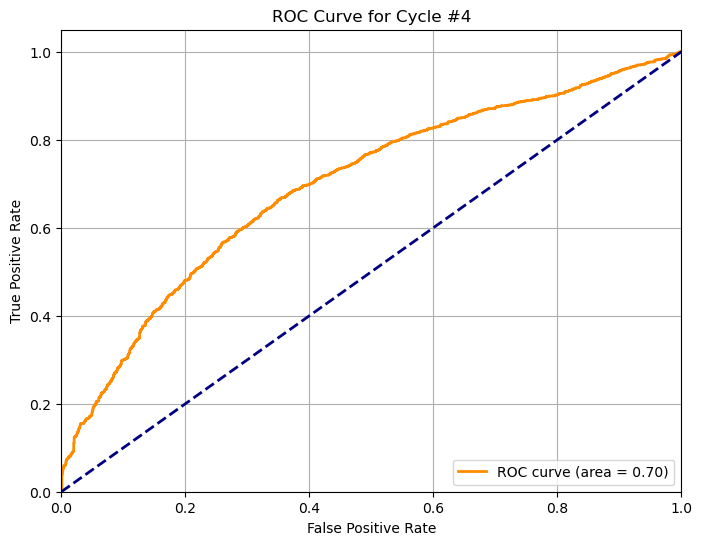

,0,1,2,3,4,5,6,7,8,9,...,4672,4673,4674,4675,4676,4677,4678,4679,4680,4681
0,0.839752,0.423542,0.068641,1.722802,-1.735943,0.096909,-0.953669,-0.499025,-2.125936,0.817507,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,-0.147117,-0.267368,1.067057
1,-0.077335,-1.016478,2.015092,-0.856428,0.056626,0.822096,-2.945610,-2.281006,-2.873473,1.868882,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,-0.147117,-0.267368,0.895979
2,-0.268522,-1.036879,0.578720,-0.675872,0.183390,-0.509941,-1.463470,1.147305,0.847366,-0.047401,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,15.280333,-0.267368,-0.373889
3,-0.443774,-0.860579,1.257114,-0.582513,0.752612,-1.008228,-0.959628,1.758676,1.017307,-0.812307,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,15.280333,-0.267368,-0.373889
4,-0.443054,-0.817711,1.042909,-0.829703,0.638874,-0.979995,-1.011023,1.845487,1.058556,-0.776416,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,15.280333,-0.267368,-0.373889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9095,-0.000517,-0.673606,1.184238,0.340804,0.097634,0.304536,0.371785,1.484618,0.069676,-1.667364,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,-0.147117,3.680240,0.923329
9096,-0.248398,-0.645120,1.283410,1.671454,0.374108,0.355141,1.215164,-1.191833,-0.166593,0.999757,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,4.136920,-0.193225,-0.147117,-0.267368,-0.066034
9097,-1.290550,-0.292128,-1.026430,-0.412335,-0.057524,-1.428088,-1.094562,0.974728,0.644113,-0.832854,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,-0.147117,-0.267368,-0.683291
9098,0.401673,0.961657,2.235932,0.841213,-1.190421,0.077739,0.884787,1.802215,1.009379,-2.061178,...,-0.266911,-0.269729,-0.176934,-0.028309,-0.128812,-0.217944,-0.193225,-0.147117,-0.267368,0.732515


'SVC'

0.4184114039307585

0.32903518234666523

'KNN'

...

0.35601117269360266

0.35601117269360266

0.35601117269360266

0.35601117269360266

RESULTS FOR CYCLE KNN#5
Accuracy: 0.6319
F1-Score: 0.7151
MCC: 0.2000
RESULTS FOR CYCLE SVC#5
Accuracy: 0.6878
F1-Score: 0.7520
MCC: 0.3318


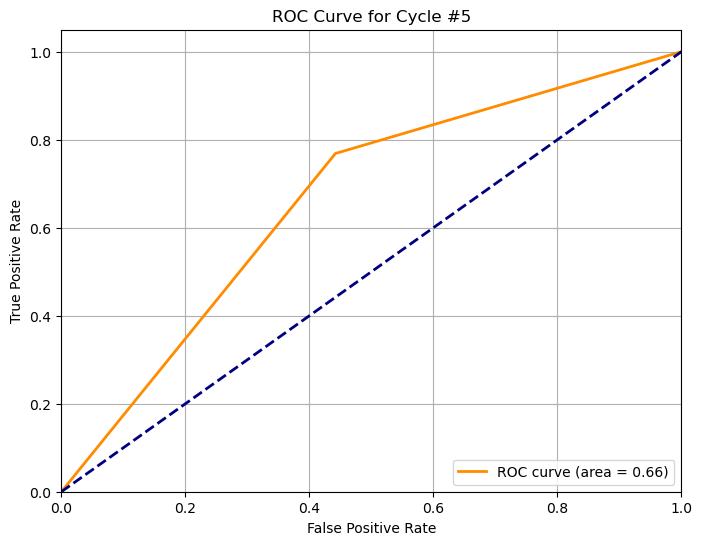

0.45504954742044745

0.4398378695955878

0.4657662424810124

[[0.3158936 ]
 [0.31035498]
 [0.16898358]
 ...
 [0.52973276]
 [0.63652146]
 [0.7254443 ]]
RESULTS FOR CYCLE MLP#5
Accuracy: 0.6735
F1-Score: 0.7399
MCC: 0.3022


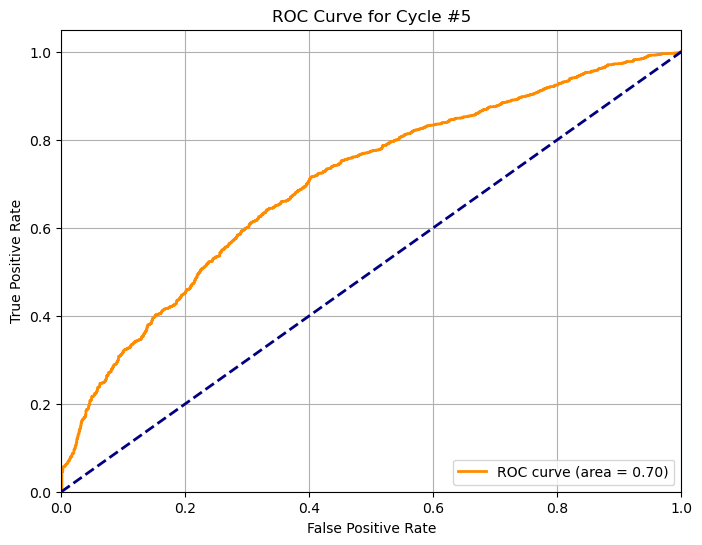

,0,1,2,3,4,5,6,7,8,9,...,4673,4674,4675,4676,4677,4678,4679,4680,4681,4682
0,-0.362871,0.474194,-2.210710,0.487549,-0.282460,0.548240,1.660081,0.645813,-0.165592,0.199201,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.526767
1,-0.840366,1.014360,-2.123913,1.079034,-0.285396,1.022341,1.255888,0.567415,0.108526,0.628241,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.526767
2,0.754068,-1.236907,-1.313147,0.803160,-1.519013,0.400649,1.406492,-0.178782,0.609697,0.340677,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-1.100242
3,0.486007,-0.951530,-0.972991,0.912983,-1.379070,0.730647,1.564937,-0.245317,0.826690,1.136411,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.895045
4,-0.532024,0.490432,-1.154146,0.487827,-1.165191,0.394470,0.463570,0.550570,0.322116,1.013349,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.910615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9075,0.539818,-2.045584,1.109002,-0.718786,-1.813000,0.209392,0.531271,-0.154407,0.131418,-1.868117,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,4.037106,-0.034319
9076,-1.176474,0.375167,1.328736,0.598682,0.752661,1.195397,-1.749841,0.380104,-0.828905,-1.012826,...,-0.28256,3.368145,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.225503
9077,-0.943930,0.734105,0.532319,0.299643,0.523621,0.167424,-0.410976,0.055956,-0.116326,-0.389458,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,5.629507,-0.129259,-0.246524,-0.621811
9078,-1.232552,-0.549025,-0.965927,-0.068212,0.291578,0.388018,0.753613,-0.320259,1.194741,-1.265672,...,-0.28256,-0.290717,-0.186197,-0.025466,-0.092178,-0.225552,-0.172984,-0.129259,-0.246524,-0.254091


'SVC'

0.3948034313010649

0.35992292496337214

'KNN'

...

0.3405946175531205

0.3405946175531205

0.3405946175531205

0.3405946175531205

RESULTS FOR CYCLE KNN#6
Accuracy: 0.6080
F1-Score: 0.6502
MCC: 0.2134
RESULTS FOR CYCLE SVC#6
Accuracy: 0.6844
F1-Score: 0.7434
MCC: 0.3344


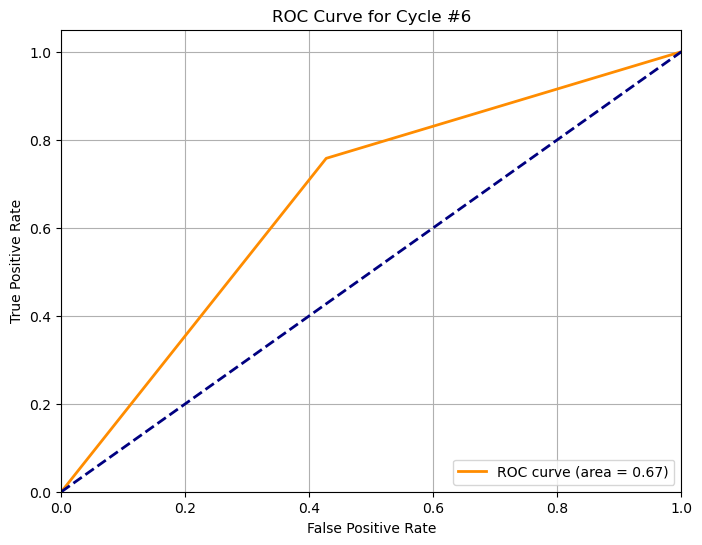

0.4425227171465966

0.43236526327767905

0.4258799005165952

[[0.26613304]
 [0.22078227]
 [0.20719849]
 ...
 [0.17775124]
 [0.57968104]
 [0.71178424]]
RESULTS FOR CYCLE MLP#6
Accuracy: 0.6783
F1-Score: 0.7364
MCC: 0.3240


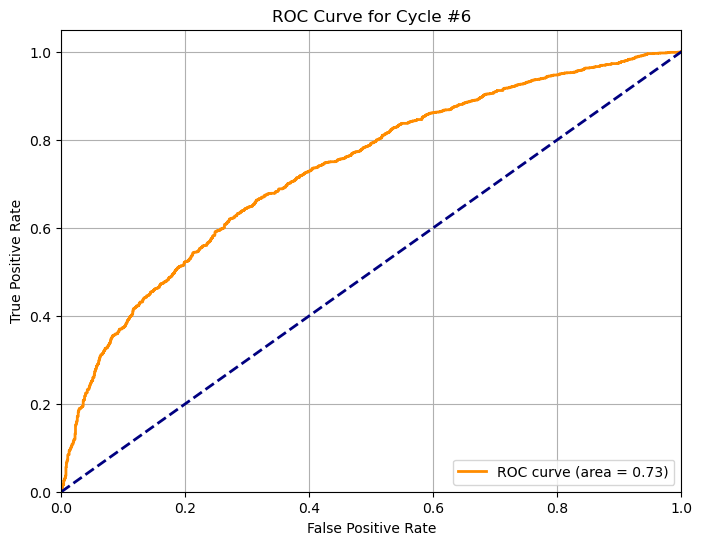

,0,1,2,3,4,5,6,7,8,9,...,4673,4674,4675,4676,4677,4678,4679,4680,4681,4682
0,1.072857,1.060931,2.131351,-0.977841,0.349096,3.149440,-2.122634,-2.970418,-2.411412,-0.056542,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.266718
1,0.455685,-1.651897,0.975928,-0.608166,-0.839453,0.657997,-1.388107,-0.653573,-1.124745,0.708659,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,-0.873396
2,0.341070,-1.318324,-0.215179,-1.162817,-0.316266,0.797769,-1.074084,-0.986432,-0.963123,1.352498,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.717268
3,-0.076875,-1.045032,2.095407,-0.868692,0.015458,0.818838,-2.873008,-2.251162,-2.926041,1.856479,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.891468
4,0.627307,1.330513,-0.589182,-2.590039,-1.038252,1.318500,-1.812075,-2.416459,-0.885126,-3.060731,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.098011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9137,-0.100899,-1.168697,-0.494339,-0.530612,-1.609042,1.060610,0.374333,0.905488,0.021551,-0.453543,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.313309
9138,0.168741,0.301614,1.103536,0.990590,0.987370,-1.391036,1.847837,0.659948,1.070446,1.147581,...,-0.24629,3.517298,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,-1.297225
9139,-0.906866,-0.156614,0.832178,1.491370,1.321600,0.720615,0.978830,-0.380321,0.613074,-0.055277,...,-0.24629,-0.272802,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.098039
9140,0.642725,-1.437901,2.384719,1.724369,-1.509171,-0.370537,0.340153,-0.293848,0.643756,-0.259265,...,-0.24629,3.517298,-0.178557,-0.03026,-0.110981,-0.22785,-0.207495,-0.116876,-0.253691,0.669902


'SVC'

0.45799997282585564

0.4104093253022367

'KNN'

...

0.33986505089672514

0.33986505089672514

0.33986505089672514

0.33986505089672514

RESULTS FOR CYCLE KNN#7
Accuracy: 0.6267
F1-Score: 0.6919
MCC: 0.2202
RESULTS FOR CYCLE SVC#7
Accuracy: 0.6648
F1-Score: 0.7252
MCC: 0.2966


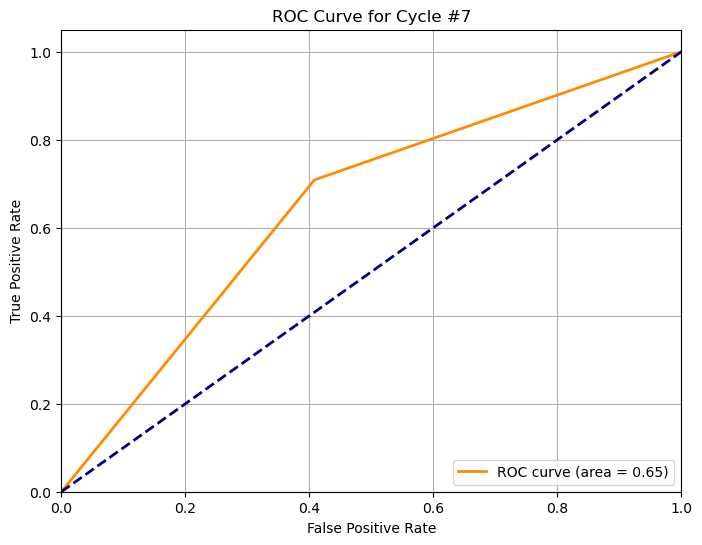

0.4810606613625324

0.4923212627881463

0.48981758540200065

[[0.17401856]
 [0.16493185]
 [0.1276067 ]
 ...
 [0.9607587 ]
 [0.79347295]
 [0.9194045 ]]
RESULTS FOR CYCLE MLP#7
Accuracy: 0.6657
F1-Score: 0.7244
MCC: 0.3013


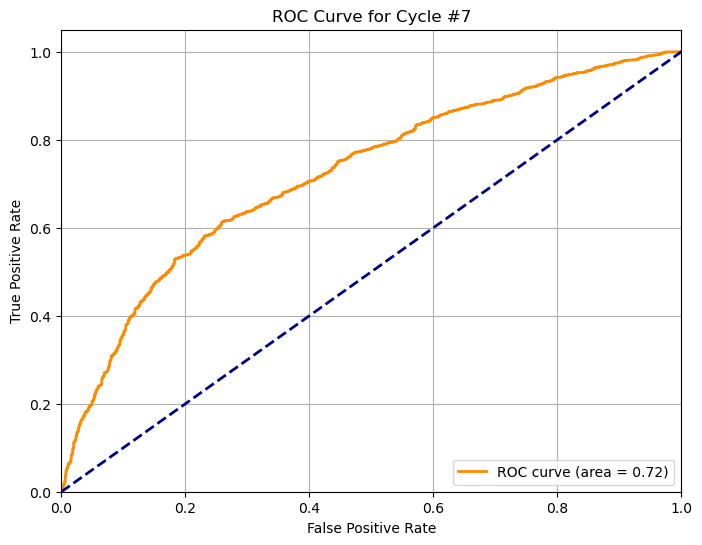

,0,1,2,3,4,5,6,7,8,9,...,4670,4671,4672,4673,4674,4675,4676,4677,4678,4679
0,-0.368861,0.472651,-2.176518,0.498607,-0.282625,0.550069,1.654680,0.669915,-0.115744,0.161716,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-0.532761
1,-0.851851,1.003114,-2.092351,1.067470,-0.285557,1.030878,1.244304,0.591532,0.159272,0.591642,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-0.532761
2,0.760932,-1.207712,-1.306145,0.802148,-1.517885,0.400390,1.397212,-0.154515,0.662087,0.303484,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-1.102044
3,0.489785,-0.927462,-0.976293,0.907770,-1.378088,0.735056,1.558081,-0.221038,0.879791,1.100862,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-0.898347
4,-0.539961,0.488597,-1.151960,0.498875,-1.164433,0.394123,0.439868,0.574691,0.373563,0.977546,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-0.913804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9019,-0.829472,-2.055611,-1.189549,0.328964,0.060823,0.500129,0.864884,-0.386204,0.035028,-1.227111,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,3.619569,0.624638
9020,-0.359149,1.121960,0.632403,-0.581417,-0.035812,-0.558404,-0.092427,0.137137,0.258172,-0.408452,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,1.93739,-0.180576,-0.15836,-0.275201,0.967520
9021,1.723268,1.759864,0.923777,-2.170993,0.118157,0.659772,-0.637868,-0.918024,-0.066005,-0.748942,...,-0.269072,0.578349,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,0.611832,0.517230
9022,-0.799776,0.188348,0.601276,1.146575,0.453690,0.042673,1.569890,-0.706917,1.268509,-0.434843,...,-0.269072,-0.281911,-0.186519,-0.03218,-0.119616,-0.21369,-0.180576,-0.15836,-0.275201,-0.194594


'SVC'

0.39755892041094987

0.29968358409258655

'KNN'

...

0.287088939850201

0.28634261558303115

0.28634261558303115

0.28634261558303115

RESULTS FOR CYCLE KNN#8
Accuracy: 0.6498
F1-Score: 0.7198
MCC: 0.2532
RESULTS FOR CYCLE SVC#8
Accuracy: 0.6769
F1-Score: 0.7359
MCC: 0.3211


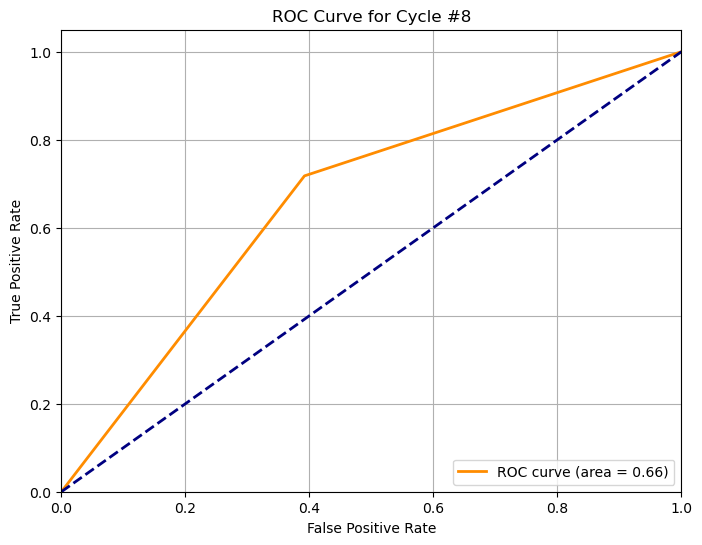

0.4360226972813336

0.40795620167673385

0.39071596126048913

[[0.3056887 ]
 [0.29336542]
 [0.35933968]
 ...
 [0.70172286]
 [0.7565358 ]
 [0.7658498 ]]
RESULTS FOR CYCLE MLP#8
Accuracy: 0.6706
F1-Score: 0.7183
MCC: 0.3319


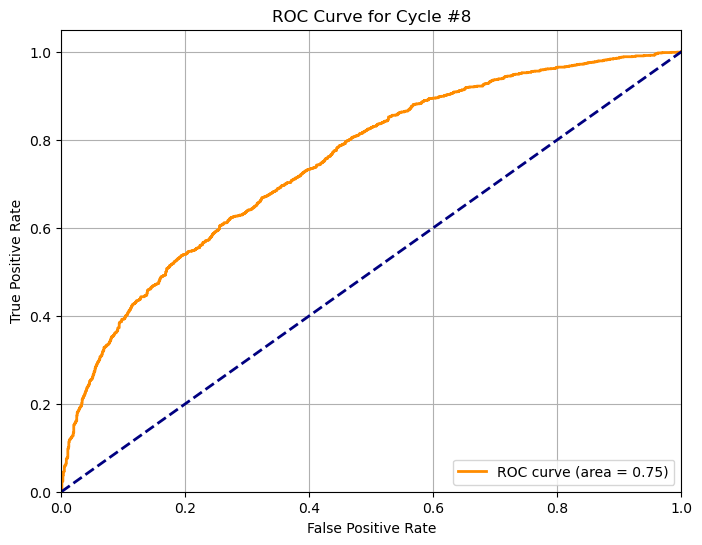

,0,1,2,3,4,5,6,7,8,9,...,4682,4683,4684,4685,4686,4687,4688,4689,4690,4691
0,-0.398097,0.398383,-2.174695,0.476509,-0.310893,0.528331,1.624137,0.693785,-0.127080,0.217761,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.511110
1,-0.866177,0.925468,-2.089807,1.035558,-0.313848,1.014652,1.222714,0.613706,0.151666,0.651526,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.511110
2,0.696821,-1.271278,-1.296867,0.774813,-1.555584,0.376936,1.372286,-0.148491,0.661300,0.360795,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-1.081218
3,0.434044,-0.992813,-0.964190,0.878613,-1.414719,0.715439,1.529645,-0.216453,0.881956,1.165295,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.877226
4,-0.563915,0.414228,-1.141361,0.476772,-1.199433,0.370598,0.435828,0.596501,0.368863,1.040877,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.892705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9185,0.315652,-0.282228,0.817690,0.500500,0.421514,0.145117,-0.809027,0.027752,-1.479984,-0.436856,...,-0.256132,3.802252,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.398546
9186,1.666653,1.175262,0.689934,-0.779200,-0.837903,-0.795172,-0.082056,-1.038068,-1.390647,2.327564,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,1.161042
9187,1.299935,-0.812677,-0.154216,1.358736,-0.930662,0.114277,1.105337,1.613827,1.362578,0.073329,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,0.488961
9188,0.142788,-0.501341,0.816575,-1.230181,1.323115,-0.650562,-0.481386,-1.018502,-0.349981,-1.207174,...,-0.256132,-0.256355,-0.191803,-0.030235,-0.116654,-0.211443,-0.203224,-0.116964,-0.235254,-0.319527


'SVC'

0.40600653829948535

0.3371252057322847

'KNN'

...

0.36383486309797

0.36383486309797

0.36383486309797

0.36383486309797

RESULTS FOR CYCLE KNN#9
Accuracy: 0.6311
F1-Score: 0.6866
MCC: 0.2428
RESULTS FOR CYCLE SVC#9
Accuracy: 0.6897
F1-Score: 0.7489
MCC: 0.3429


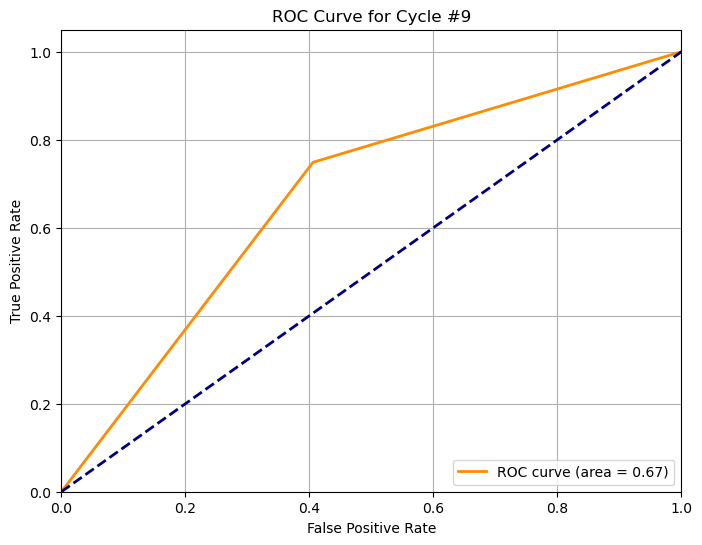

0.43639580609348627

0.4287668465004218

0.42943582114580525

[[0.1756052 ]
 [0.31914282]
 [0.2301603 ]
 ...
 [0.688363  ]
 [0.75587803]
 [0.76605195]]
RESULTS FOR CYCLE MLP#9
Accuracy: 0.6956
F1-Score: 0.7468
MCC: 0.3669


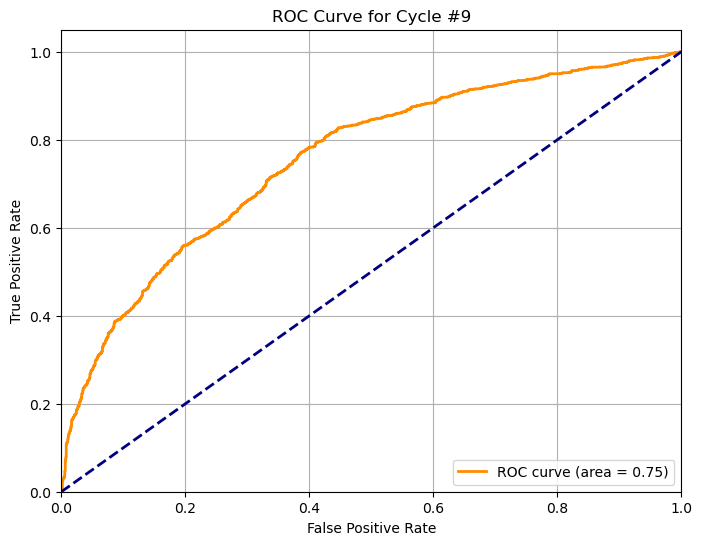

,0,1,2,3,4,5,6,7,8,9,...,4670,4671,4672,4673,4674,4675,4676,4677,4678,4679
0,-0.398955,0.475555,-2.154616,0.514199,-0.290527,0.563089,1.666291,0.672290,-0.122348,0.200639,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-0.552788
1,-0.865947,1.010129,-2.070622,1.094777,-0.293472,1.039749,1.256101,0.593376,0.151619,0.621650,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-0.552788
2,0.693415,-1.217829,-1.286027,0.823990,-1.531011,0.414702,1.408940,-0.157736,0.652514,0.339467,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-1.126807
3,0.431250,-0.935407,-0.956851,0.931788,-1.390622,0.746480,1.569736,-0.224710,0.869388,1.120311,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-0.921416
4,-0.564388,0.491624,-1.132158,0.514472,-1.176064,0.408489,0.452029,0.576420,0.365091,0.999551,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-0.937000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9165,-0.559116,-0.316833,-0.743657,0.331130,-0.274339,-0.192103,1.271787,-0.362212,1.065036,0.173124,...,-0.239239,-0.286866,4.843928,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,-0.468204
9166,0.103693,1.105898,1.446070,0.033258,1.499860,1.628079,-0.423182,0.599961,-0.314486,-1.693619,...,-0.239239,3.461006,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,3.871968,-0.204857
9167,-0.354021,0.602602,-0.114632,0.084008,0.154353,-0.715702,0.458877,0.196505,0.491587,-0.366159,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,0.764176
9168,-0.324518,-0.391576,0.457024,-1.063328,-0.199520,0.681556,0.559275,-0.399649,0.718449,0.343193,...,-0.239239,-0.286866,-0.195760,-0.027654,-0.124579,-0.215437,-0.197687,-0.118512,-0.253788,0.249267


'SVC'

0.39515224187084963

0.38678223350115887

'KNN'

...

0.3439102646792576

0.3439102646792576

0.3439102646792576

0.3439102646792576

RESULTS FOR CYCLE KNN#10
Accuracy: 0.6323
F1-Score: 0.7090
MCC: 0.2106
RESULTS FOR CYCLE SVC#10
Accuracy: 0.6722
F1-Score: 0.7411
MCC: 0.2958


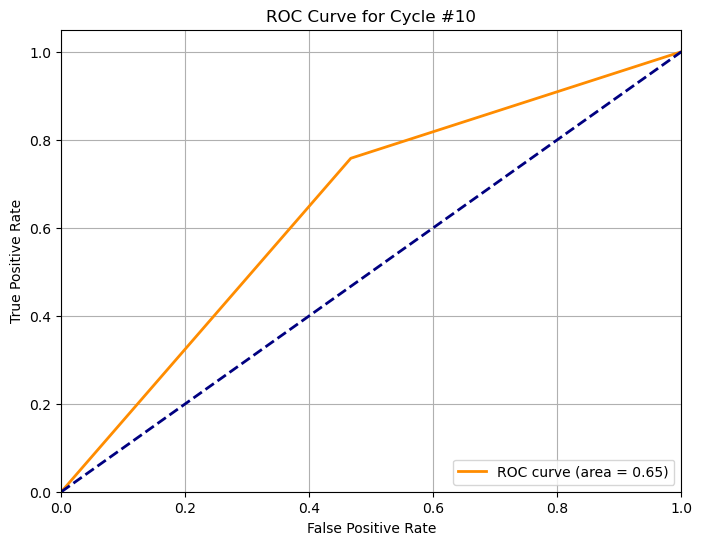

0.4129929564617774

0.41073257066165103

0.4041890757245858

[[0.09138227]
 [0.16854176]
 [0.18608895]
 ...
 [0.7178178 ]
 [0.5035613 ]
 [0.7121807 ]]
RESULTS FOR CYCLE MLP#10
Accuracy: 0.6883
F1-Score: 0.7638
MCC: 0.3161


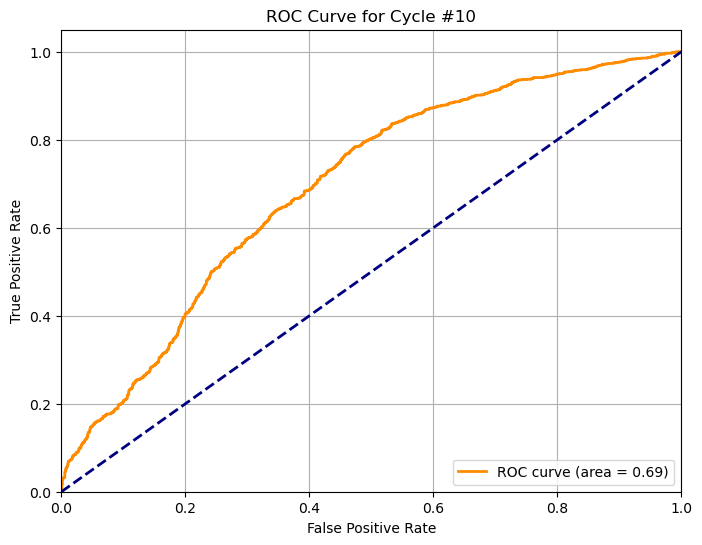

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

# --- Your main loop starts here ---
for i in range(1,11):
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)
    display(pd.DataFrame(x1))

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()

    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        j["gamma"]= j["gamma"] if j["gamma"] == 'auto' or j["gamma"] == 'scale' else float(j["gamma"])
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        display(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    pred_proba = pred > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
        # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run_mlp:
            best_mcc_this_run_mlp = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = pred_test_mlp[-1]
    print(pred_proba)
    pred = pred_proba > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)



    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ---



In [19]:
all_y3 =[]
mcc_list = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [20]:
display(mcc_list)

[0.36938780526481274,
 0.3601101510752721,
 0.3807337641943471,
 0.28866143988556603,
 0.30224919124005856,
 0.32403405930259804,
 0.30126524497399515,
 0.3319277578777526,
 0.36691882960111233,
 0.31611515455535144]

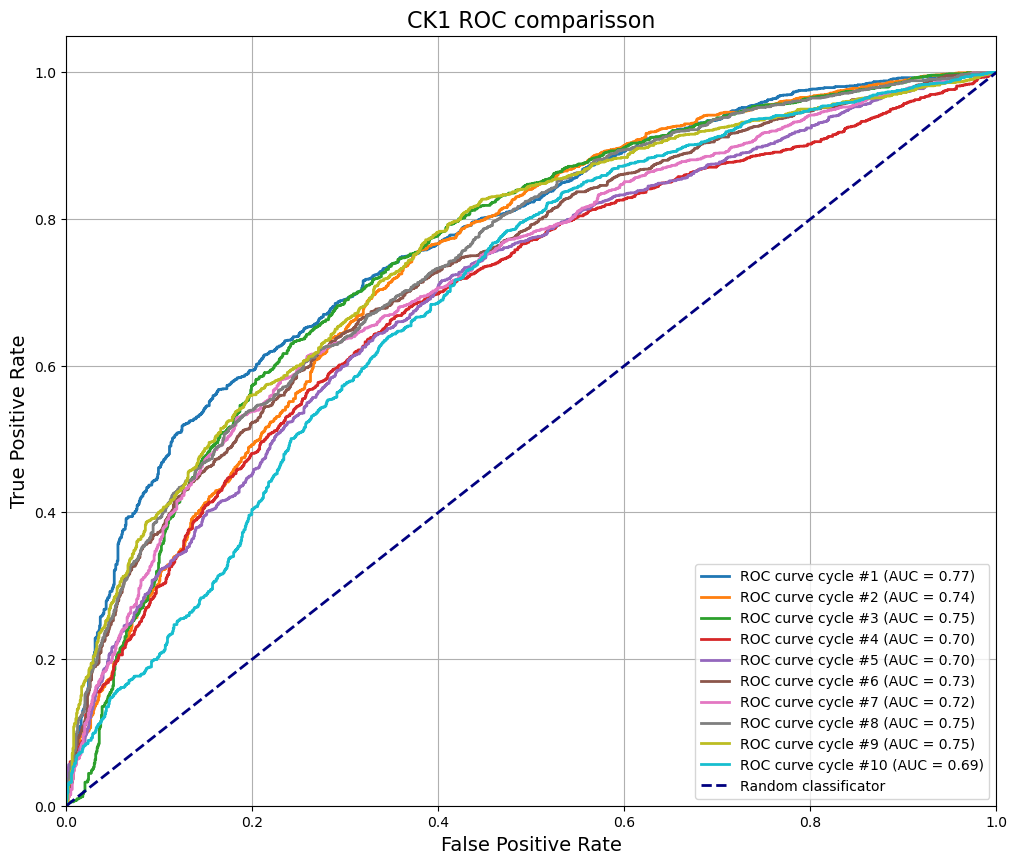

In [21]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

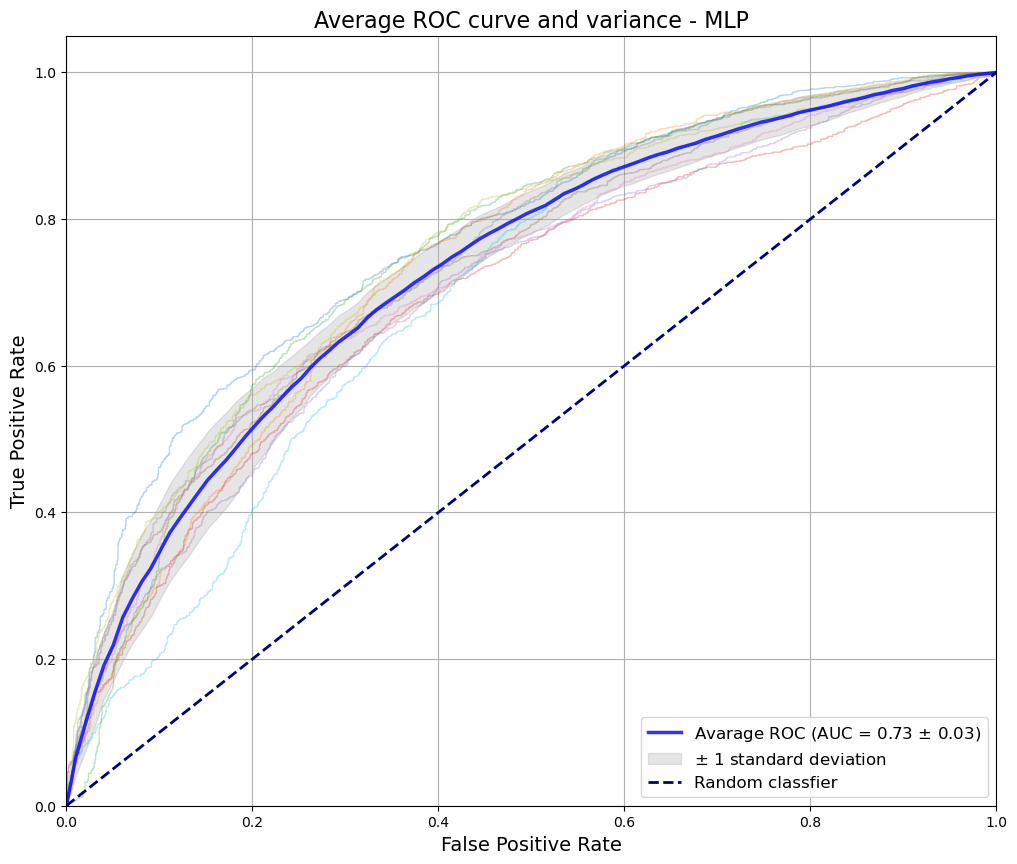

In [52]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_herg.png', dpi=300, bbox_inches='tight')
plt.show()


In [2]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1


NameError: name 'pd' is not defined

In [34]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    print(mcc_list_mlp[-1])

1
0.36938780526481274
2
0.3601101510752721
3
0.3807337641943471
4
0.28866143988556603
5
0.30224919124005856
6
0.32403405930259804
7
0.30126524497399515
8
0.3319277578777526
9
0.36691882960111233
10
0.31611515455535144


In [35]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


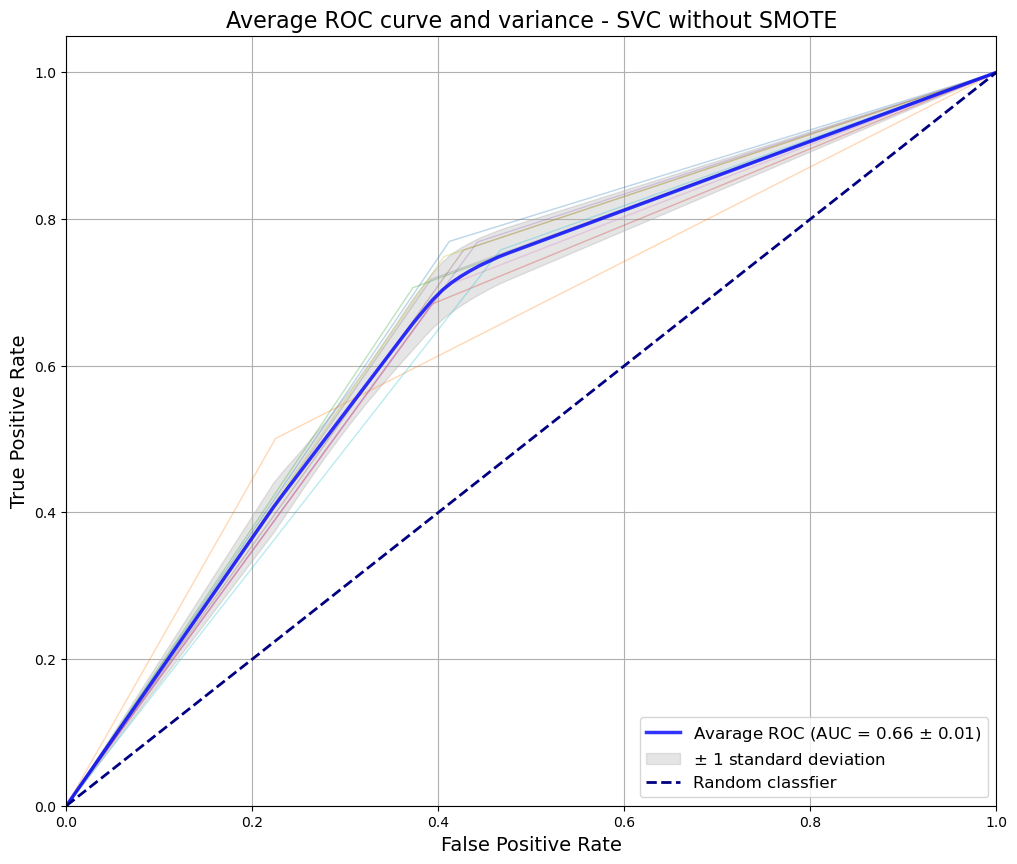

In [26]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - SVC without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

In [29]:
mcc_list_mlp_ws = [0.36516866666325953,
  0.3474510270905953,
  0.3920867801735328,
  0.29278802036895185,
  0.3323989051785469,
  0.3707082392468813,
  0.322100597087428,
  0.33059045051042923,
  0.360631759127952,
  0.3153596025434111]
mcc_list_knn_ws =  [0.24586271439239007,
  0.253875502629269,
  0.2324225313895414,
  0.20061156925086157,
  0.23027099866086143,
  0.2102578699775346,
  0.21023667371093624,
  0.23238639087490695,
  0.23662813675806665,
  0.19957416446935453]
mcc_list_svc_ws =   [0.3504480275491407,
  0.36742629281305156,
  0.3396796127161722,
  0.28788908172676325,
  0.3191992185556172,
  0.33751067919095,
  0.28286276450936115,
  0.3461039081391339,
  0.34917866657722385,
  0.3085197862909876]








In [30]:
f1_list_mlp_ws = [0.7569275644141954,
  0.7179621848739496,
  0.7298355520751761,
  0.6901408450704225,
  0.7386419149975574,
  0.7222651222651223,
  0.7229813664596273,
  0.7258185453636591,
  0.7300127713920818,
  0.7371221281741234]
f1_list_knn_ws =   [0.7149059334298119,
  0.7158456685270566,
  0.7145877378435518,
  0.6953801732435033,
  0.7170697346795022,
  0.6914639961850262,
  0.6964028776978417,
  0.7177078440582433,
  0.7130600571973308,
  0.7100536505714952]
f1_list_svc_ws =    [0.7588838540424517,
  0.756175103937393,
  0.7405786530513008,
  0.7225743539736714,
  0.7525629077353215,
  0.7482452035563875,
  0.7235166946913284,
  0.750779563444471,
  0.755067970426902,
  0.753060753060753]












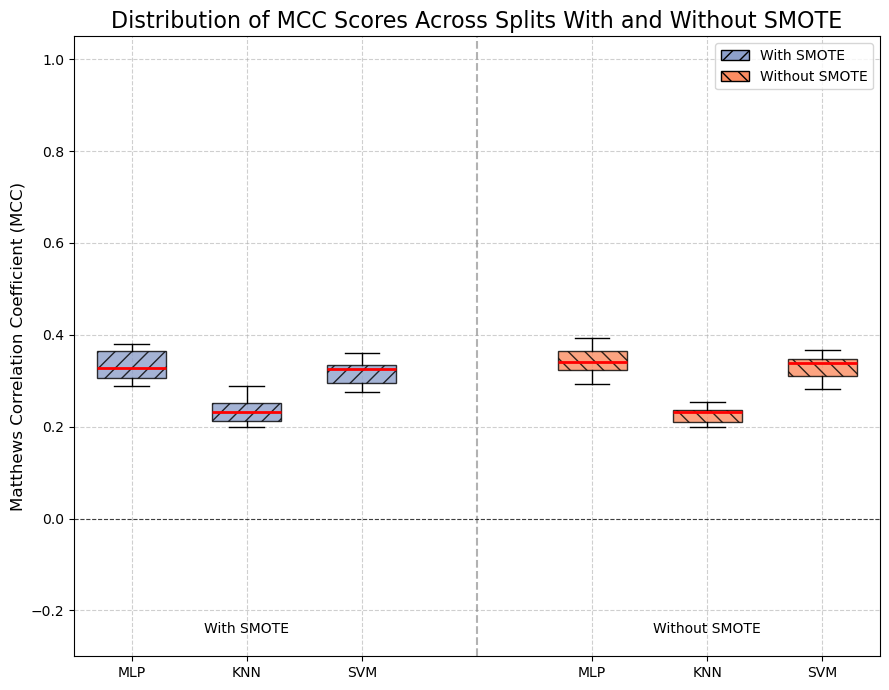

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_herg.png', dpi=300, bbox_inches='tight')
plt.show()


In [41]:
import pandas as pd
import numpy as np


def create_string(list_vals):
    return f"{np.mean(list_vals):.4f} ± {np.var(list_vals, ddof=1):.4f}"
# Příklad dat
data = {
    "Model": ["MLP", "MLP without SMOTE", "KNN", "KNN without SMOTE", "SVM", "SVM without SMOTE"],
    "F1": [create_string(f1_list_mlp), create_string(f1_list_mlp_ws), create_string(f1_list_knn), create_string(f1_list_knn_ws), create_string(f1_list_svc), create_string(f1_list_svc_ws)],
    "MCC": [create_string(mcc_list_mlp), create_string(mcc_list_mlp_ws), create_string(mcc_list_knn), create_string(mcc_list_knn_ws), create_string(mcc_list_svc), create_string(mcc_list_svc_ws)]
}


df = pd.DataFrame(data)
latex_code = df.to_latex(index=False, escape=False)
print(latex_code)

\begin{tabular}{lll}
\toprule
Model & F1 & MCC \\
\midrule
MLP & 0.7400 ± 0.0002 & 0.3341 ± 0.0011 \\
MLP without SMOTE & 0.7272 ± 0.0003 & 0.3429 ± 0.0009 \\
KNN & 0.7400 ± 0.0002 & 0.2337 ± 0.0008 \\
KNN without SMOTE & 0.7086 ± 0.0001 & 0.2252 ± 0.0004 \\
SVM & 0.7258 ± 0.0019 & 0.3172 ± 0.0008 \\
SVM without SMOTE & 0.7461 ± 0.0002 & 0.3289 ± 0.0008 \\
\bottomrule
\end{tabular}

